# Capstone Function 2
Imagine a black box, or a mystery ML model, that takes two numbers as input, and returns a log-likelihood score. Goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.
To tackle this, you use Bayesian Optimisation, which selects the next inputs based on what it has learnt so far.  Balances exploration iwth exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

 Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

### Step 1: Import Required Libraries

Import necessary libraries for Bayesian Optimization, data handling, and visualization.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

### Step 2: Load and Display Initial Data

Load the initial input and output data for the noisy log-likelihood optimization problem.

In [ ]:
# Load initial data
X_init = np.load('../../data/f2/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f2/updated_outputs - Week 4.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape}")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

In [ ]:
# Visualize initial data points in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=200, cmap='viridis', edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Output Value (Log-Likelihood)')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Initial Data Points - Noisy Log-Likelihood Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the best point
best_idx = y_init.argmax()
plt.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label=f'Best (y={y_init[best_idx]:.6f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Gaussian Process Kernel**: Matern 5/2 (BoTorch default)
   - **Why**: Robust to noise, which is critical for this noisy log-likelihood function
   - Twice differentiable, providing smooth predictions

2. **Acquisition Function**: Expected Improvement (EI)
   - **Why**: Handles noisy observations well by averaging over uncertainty
   - Good at avoiding local optima through exploration-exploitation balance
   - Well-suited for problems with multiple local peaks

3. **Number of Restarts for Acquisition Optimization**: 10
   - **Why**: Important for noisy functions to avoid getting stuck in local optima
   - Multiple restarts ensure robust acquisition function optimization

4. **Number of Raw Samples**: 512
   - **Why**: Thorough initial sampling to find good starting points
   - Helps navigate complex landscape with potential local maxima

5. **Input Bounds**: [0, 1.0] for all dimensions
   - **Why**: Required by submission format - all inputs must be in range [0, 1.0]

6. **Standardize Outputs**: Yes (automatic in SingleTaskGP)
   - **Why**: Critical for numerical stability with varying output scales
   - GP noise model learns appropriate noise level from data

In [ ]:
# Define hyperparameters
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]  # Number of dimensions
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)

NUM_RESTARTS = 10  # Number of restarts for acquisition function optimization
RAW_SAMPLES = 512  # Number of initial random samples for acquisition optimization

print("Hyperparameters:")
print(f"  Input bounds: [0, 1.0] for all {N_DIM} dimensions")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2 (default)")
print(f"  Number of restarts: {NUM_RESTARTS}")
print(f"  Raw samples: {RAW_SAMPLES}")
print(f"  Output standardization: Yes (SingleTaskGP handles this)")

### Step 4: Build Gaussian Process Surrogate Model

Create and train a Gaussian Process model on the initial data. The GP learns patterns in the noisy observations.

In [ ]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create Gaussian Process model
gp_model = SingleTaskGP(X_train, y_train)

# Define the marginal log likelihood
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

# Fit the GP model to the data
print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")
print(f"\nNote: Noise variance estimates observational noise in the log-likelihood function")

### Step 5: Optimize Acquisition Function to Propose Next Sample

Use Expected Improvement to find the next most promising point to evaluate.

In [ ]:
# Create Expected Improvement acquisition function
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize the acquisition function
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Extract the proposed next point
next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement value: {acq_value.item():.6f}")

### Step 6: Visualize Surrogate Function

Visualize the GP mean prediction and uncertainty across the 2D search space.

In [ ]:
# Create a grid for visualization
n_grid = 50
x1_range = np.linspace(BOUNDS[0, 0].item(), BOUNDS[1, 0].item(), n_grid)
x2_range = np.linspace(BOUNDS[0, 1].item(), BOUNDS[1, 1].item(), n_grid)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_grid_torch = torch.tensor(X_grid, dtype=torch.float64)

# Get GP predictions
gp_model.eval()
with torch.no_grad():
    posterior = gp_model.posterior(X_grid_torch)
    mean = posterior.mean.numpy().reshape(n_grid, n_grid)
    std = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GP Mean Prediction
im1 = axes[0].contourf(X1_grid, X2_grid, mean, levels=20, cmap='viridis')
axes[0].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[0].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('GP Mean Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Predicted Log-Likelihood')

# Plot 2: GP Uncertainty
im2 = axes[1].contourf(X1_grid, X2_grid, std, levels=20, cmap='plasma')
axes[1].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[1].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('GP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Standard Deviation')

plt.tight_layout()
plt.show()

print(f"GP captures trends despite noise. Uncertainty highest in unexplored regions.")

### Step 7: Visualize Acquisition Function

Show the Expected Improvement values across the search space.

In [ ]:
# Compute Expected Improvement values across the grid
with torch.no_grad():
    ei_values = EI(X_grid_torch.unsqueeze(1)).numpy().reshape(n_grid, n_grid)

# Visualize Expected Improvement
plt.figure(figsize=(10, 8))
im = plt.contourf(X1_grid, X2_grid, ei_values, levels=20, cmap='hot')
plt.scatter(X_init[:, 0], X_init[:, 1], c='cyan', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
plt.scatter(next_point[0], next_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point (max EI)', zorder=6)
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Expected Improvement Acquisition Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EI balances exploring uncertain regions and exploiting promising areas.")

### Step 8: Track Optimization Progress

Monitor the best observed value over iterations.

In [ ]:
# Track the best value found so far at each iteration
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Log-Likelihood', fontsize=12)
plt.title('Optimization Progress - Best Value Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples, awaiting next evaluation...")
print(f"\nNext submission: {next_point}")

### Step 9: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
if acq_value.item() > 0.1:
    print("  → High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  → Moderate EI: Some exploration potential remains")
else:
    print("  → Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**Initial Submission Complete**

- Loaded 10 initial data points for noisy 2D log-likelihood optimization
- Built Gaussian Process surrogate model with Matern 5/2 kernel
- Model handles noisy observations through learned noise variance
- Used Expected Improvement acquisition function
- Proposed next sample point for evaluation
- Visualized surrogate function, uncertainty, and acquisition landscape

**Key Considerations for Noisy Function:**
- GP noise model captures observation uncertainty
- Multiple local optima require careful exploration
- Expected Improvement naturally handles noise through probabilistic predictions

**Next Steps:**
1. Submit the proposed point for evaluation
2. Receive the observation result
3. Add to dataset and retrain model
4. Propose next point (repeat process)

## Week 5 — Random Forest Surrogate

This section replaces the Gaussian Process surrogate with a **Random Forest** model for the log-likelihood estimation problem (f2).

**Why Random Forest for f2?**
- Handles noise well — individual trees may overfit, but the ensemble averages out noise
- No distributional assumptions about the objective function (unlike GP which assumes a Gaussian prior)
- Provides natural uncertainty estimates via variance across individual tree predictions
- Feature importance scores show which input dimensions matter most

**Acquisition Strategy:** Upper Confidence Bound (UCB) using tree-variance as uncertainty estimate.

### Step 1: Load Week 5 Data

Load the cumulative Week 5 data (15 total samples = initial + weekly submissions).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f2/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f2/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Input range:  [{X_w5.min():.6f}, {X_w5.max():.6f}]")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed value: {y_w5.max():.6f} at index {y_w5.argmax()}")
print(f"Best observed point: {X_w5[y_w5.argmax()]}")

### Step 2: Random Forest Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 100**: Number of trees in the forest. With only 15 samples, 100 trees provides sufficient ensemble diversity without excessive computation.

2. **max_depth = 5**: Maximum tree depth. Capped at 5 to prevent overfitting on just 15 samples. Each leaf should contain at least 2-3 samples.

3. **min_samples_split = 3**: Minimum samples required to split a node. Set to 3 to ensure no split creates nodes with too few samples.

4. **min_samples_leaf = 2**: Minimum samples in a leaf node. Set to 2 to prevent extreme predictions from single-sample leaves.

5. **random_state = 42**: Fixed seed for reproducibility.

6. **oob_score = True**: Out-of-bag score provides a free validation metric — each tree's OOB samples approximate hold-out error.

7. **UCB kappa = 2.0**: Exploration parameter for tree-variance-based uncertainty. Tree std is well-calibrated for this kappa value — provides good exploration while respecting the model's predictions.

8. **n_candidates = 20,000**: Random candidate points for UCB evaluation.

In [ ]:
# --- Random Forest Hyperparameters ---
N_ESTIMATORS = 100
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 3
MIN_SAMPLES_LEAF = 2
RANDOM_STATE = 42
KAPPA = 2.0
N_CANDIDATES = 20000

print("Random Forest Surrogate Hyperparameters:")
print(f"  n_estimators:      {N_ESTIMATORS}")
print(f"  max_depth:         {MAX_DEPTH}")
print(f"  min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf:  {MIN_SAMPLES_LEAF}")
print(f"  random_state:      {RANDOM_STATE}")
print(f"  oob_score:         True")
print(f"  UCB kappa:         {KAPPA}")
print(f"  UCB candidates:    {N_CANDIDATES}")

### Step 3: Train Random Forest Model

Fit the Random Forest on all available data. Display the OOB score and feature importance per input dimension.

In [ ]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    oob_score=True
)
rf_model.fit(X_w5, y_w5)

# Display results
print("Random Forest Training Results:")
print(f"  OOB Score (R²):  {rf_model.oob_score_:.6f}")
print(f"  Number of trees: {rf_model.n_estimators}")
print()
print("Feature Importance:")
for i, imp in enumerate(rf_model.feature_importances_):
    print(f"  x{i+1}: {imp:.4f} ({'*' * int(imp * 20)})")

### Step 4: UCB Acquisition Function

Compute the Upper Confidence Bound using:
- **mu(x)** = mean prediction across all trees (ensemble mean)
- **sigma(x)** = standard deviation of individual tree predictions (tree variance)
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.0

In [ ]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Get mean prediction from the ensemble
mu = rf_model.predict(candidates)

# Get uncertainty: std across individual tree predictions
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
sigma = tree_predictions.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6f}")
print(f"  Tree std (sigma):   {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")

### Step 5: Visualize Random Forest Surrogate

Full 2D contour plot of the RF mean prediction and uncertainty over the search space.

In [ ]:
# Create evaluation grid
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# RF predictions and uncertainty on grid
grid_mu = rf_model.predict(grid_points).reshape(n_grid, n_grid)
grid_tree_preds = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
grid_sigma = grid_tree_preds.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RF mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, 0], X_w5[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[0], next_point_w5[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title('RF Mean Prediction')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Tree variance uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, 0], X_w5[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('Tree Variance Uncertainty')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(2)]
ax3.barh(dims, rf_model.feature_importances_, color='steelblue')
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

In [ ]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places.

In [ ]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate: Random Forest ({N_ESTIMATORS} trees, max_depth={MAX_DEPTH})")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"OOB Score: {rf_model.oob_score_:.6f}")
print(f"Next point: {next_point_w5}")
print(f"RF prediction: {mu[best_idx]:.6f}")
print(f"Tree uncertainty: {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

### Model Comparison

**Random Forest vs GP (Initial Section):**
- The GP model uses a Matern 5/2 kernel with Expected Improvement — it assumes smooth, continuous functions and provides calibrated uncertainty via the posterior distribution.
- The Random Forest makes no smoothness assumptions and builds predictions from decision boundaries. Uncertainty comes from tree disagreement rather than a probabilistic model.
- For f2's log-likelihood estimation problem, RF should capture the moderate-valued landscape well since tree ensembles handle the output range without distributional issues.
- Key trade-off: GP provides better-calibrated uncertainty for UCB, but RF is more robust to non-stationarity in the objective function.

## Week 6 — Random Forest Surrogate

This section continues the Random Forest surrogate from Week 5 with a **reduced exploration parameter** (κ decreased from 2.0 to 0.5) to focus on exploitation.

**Why decrease κ for f2?**
- Week 5's Random Forest achieved a reasonable OOB score, indicating the model has learned f2's landscape
- With 16 data points and a well-fitted model, we shift focus from exploring new regions to exploiting the predicted optimum
- κ=0.5 makes the mean prediction (μ) dominate the acquisition function — the uncertainty term (σ) acts as a small tiebreaker rather than a major driver
- This exploitation strategy aims to refine the best-observed region

**Acquisition Strategy:** UCB with κ=0.5 (exploitation) using tree-variance as uncertainty estimate.

### Step 1: Load Week 6 Data

Load the cumulative Week 6 data (16 total samples = initial 10 + 6 weekly submissions).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f2/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f2/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Input range:  [{X_w6.min():.6f}, {X_w6.max():.6f}]")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed value: {y_w6.max():.6f} at index {y_w6.argmax()}")
print(f"Best observed point: {X_w6[y_w6.argmax()]}")

### Step 2: Random Forest Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 100**: Same as Week 5. 100 trees provides sufficient ensemble diversity for 16 samples.
2. **max_depth = 5**: Same as Week 5. Prevents overfitting on small dataset.
3. **min_samples_split = 3**, **min_samples_leaf = 2**: Same as Week 5.
4. **random_state = 42**: Fixed seed for reproducibility.
5. **oob_score = True**: Out-of-bag score for validation.
6. **UCB kappa = 0.5**: **Reduced from Week 5's κ=2.0** — strong exploitation focus. The mean prediction now contributes ~2× more than uncertainty to UCB.
7. **n_candidates = 20,000**: Same as Week 5.

In [ ]:
# --- Random Forest Hyperparameters ---
N_ESTIMATORS = 100
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 3
MIN_SAMPLES_LEAF = 2
RANDOM_STATE = 42
KAPPA = 0.5              # Exploitation focus (Week 5: 2.0 → Week 6: 0.5)
N_CANDIDATES = 20000

print("Random Forest Surrogate Hyperparameters:")
print(f"  n_estimators:      {N_ESTIMATORS}")
print(f"  max_depth:         {MAX_DEPTH}")
print(f"  min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf:  {MIN_SAMPLES_LEAF}")
print(f"  random_state:      {RANDOM_STATE}")
print(f"  oob_score:         True")
print(f"  UCB kappa:         {KAPPA} (Week 5: 2.0 → Week 6: 0.5)")
print(f"  UCB candidates:    {N_CANDIDATES}")

### Step 3: Train Random Forest Model

Fit the Random Forest on all available Week 6 data. Display the OOB score and feature importance per input dimension.

In [ ]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    oob_score=True
)
rf_model.fit(X_w6, y_w6)

# Display results
print("Random Forest Training Results:")
print(f"  OOB Score (R²):  {rf_model.oob_score_:.6f}")
print(f"  Number of trees: {rf_model.n_estimators}")
print()
print("Feature Importance:")
for i, imp in enumerate(rf_model.feature_importances_):
    print(f"  x{i+1}: {imp:.4f} ({'*' * int(imp * 20)})")

### Step 4: UCB Acquisition Function

Compute the Upper Confidence Bound using:
- **μ(x)** = mean prediction across all trees (ensemble mean)
- **σ(x)** = standard deviation of individual tree predictions (tree variance)
- **UCB(x) = μ(x) + κ · σ(x)** where κ = 0.5 (exploitation focus)

In [ ]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Get mean prediction from the ensemble
mu = rf_model.predict(candidates)

# Get uncertainty: std across individual tree predictions
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
sigma = tree_predictions.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w6 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6f}")
print(f"  Tree std (sigma):   {sigma[best_idx]:.6f}")
print(f"  Exploitation contribution (μ): {mu[best_idx]:.6f}")
print(f"  Exploration contribution (κ·σ): {KAPPA * sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w6}")

### Step 5: Visualize Random Forest Surrogate

Full 2D contour plot of the RF mean prediction and tree-variance uncertainty over the [0,1]² search space, with feature importance.

In [ ]:
# Create evaluation grid
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# RF predictions and uncertainty on grid
grid_mu = rf_model.predict(grid_points).reshape(n_grid, n_grid)
grid_tree_preds = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
grid_sigma = grid_tree_preds.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RF mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w6[:, 0], X_w6[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w6[0], next_point_w6[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title('RF Mean Prediction')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Tree variance uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w6[:, 0], X_w6[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('Tree Variance Uncertainty')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(2)]
ax3.barh(dims, rf_model.feature_importances_, color='steelblue')
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all 16 observations.

In [ ]:
# Convergence plot
running_max = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w6) + 1), y_w6, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 6)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w6.max():.6f}")
print(f"Achieved at observation: {y_w6.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places, clamped to [0.0, 1.0].

In [ ]:
# Format submission query
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0.0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w6 = format_query(next_point_w6)

print("=" * 60)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate: Random Forest ({N_ESTIMATORS} trees, max_depth={MAX_DEPTH})")
print(f"Acquisition: UCB (κ={KAPPA})")
print(f"Strategy: EXPLOITATION (κ reduced from 2.0 to 0.5)")
print(f"OOB Score: {rf_model.oob_score_:.6f}")
print(f"Next point: {next_point_w6}")
print(f"RF prediction: {mu[best_idx]:.6f}")
print(f"Tree uncertainty: {sigma[best_idx]:.6f}")
print(f"\n>>> SUBMISSION: {submission_query_w6}")
print("=" * 60)

# Research
Below is a **battle‑tested Bayesian Optimization (BO) recipe** for your NeurIPS‑style black‑box: a **2‑D input**, **noisy log‑likelihood** objective, with **multiple local optima**. It’s designed to (a) stay robust under noise, (b) avoid getting trapped early, and (c) converge quickly on the global peak.

***

## TL;DR (recommended stack)

*   **Surrogate**: Gaussian Process (GP) with **Matérn‑5/2 kernel**, **ARD lengthscales**, **constant mean**, **Gaussian noise** (optionally Student‑t likelihood if heavy‑tailed noise).
*   **Acquisition**: **Noisy Expected Improvement (NEI)** (or **qNEI** if batching).
*   **Key hyperparameters & practices**:
    *   **Initialization**: 12–20 Sobol points (2–4 duplicated to learn noise).
    *   **UCB warm‑start** (high exploration) → then switch to **NEI**.
    *   **Multi‑start** acq optimizer + **random restarts**.
    *   Optional: **TuRBO‑style trust region** if you keep getting stuck.

If you prefer a non‑GP surrogate for non‑smoothness or outliers: **BART** (Bayesian Additive Regression Trees) or **Random Forest** with quantile uncertainty + UCB works very well in practice.

***

## 1) Surrogate model

### Option A (primary): **GP (Matérn‑5/2, ARD)**

The 2‑D setting is ideal for GPs. Matérn‑5/2 is smooth but not too smooth, and ARD lets each input dimension adapt its own lengthscale.

*   **Mean**: constant (learned)
*   **Kernel**: Matérn‑5/2 with **ARD lengthscales** $$\ell_1,\ell_2$$
*   **Likelihood**:
    *   Start with **homoscedastic Gaussian noise** $$\sigma_n^2$$
    *   If you observe outliers/heavy tails → switch to a **Student‑t likelihood** (same modeling flow, more robust)
*   **Output transform**: standardize $$y$$ (z‑score); also consider **$$ \log(1 + (y - \min y)_+)$$** if the dynamic range is huge

> Why GP here? In low dimensions, GPs provide calibrated uncertainty, handle multi‑modality with the right acquisition, and are sample‑efficient for expensive/noisy objectives.

### Option B (robust alternative): **BART** (or RF + uncertainty)

If the response is very **rugged** or has **occasional spikes/outliers**, BART or a **Random Forest** regressor with **quantile‑based uncertainty** can be extremely robust. Pair it with **UCB** (see Section 2).

***

## 2) Acquisition function

### **Noisy Expected Improvement (NEI)** — recommended

NEI naturally accounts for observation noise (by “fantasizing” the latent objective) and works reliably in multi‑modal surfaces. Use **qNEI** if you evaluate a batch of $$q$$ points per BO iteration.

**When to prefer something else?**

*   **Knowledge Gradient (KG)**: excellent under noise, but computationally heavier.
*   **UCB**: very strong **exploration** early on; a good warm‑start policy.
*   **Thompson Sampling (TS)**: a nice complement to UCB/NEI for extra diversity.

> **Practical playbook**: Start with **UCB** (high exploration weight) for the first 2–3 iterations, then switch to **NEI/qNEI** for stable progress.

***

## 3) Hyperparameters & settings (ready to use)

### 3.1 GP hyperparameters (with sensible priors)

Assume the input domain is scaled to $$[0,1]^2$$.

*   **Lengthscales $$\ell_1,\ell_2$$** (ARD):
    *   Prior: $$\log \ell_i \sim \mathcal{N}(\log 0.25, 1.0^2)$$
    *   Initialization: $$\ell_i = 0.25$$ (¼ of domain width)
*   **Signal variance $$\sigma_f^2$$**:
    *   Prior: half‑Cauchy or log‑normal; init so that $$\sigma_f \approx \text{std}(y)$$
*   **Noise variance $$\sigma_n^2$$**:
    *   Prior: half‑Cauchy with scale \~ $$0.1\,\text{var}(y)$$
    *   Start with a modest value (e.g., $$0.05\,\text{var}(y)$$) if you don’t replicate observations
*   **Jitter**: $$10^{-6}$$ to $$10^{-8}$$ for numerical stability
*   **Fitting**: maximize the **marginal log‑likelihood** with **L‑BFGS‑B**, 10–20 random restarts

### 3.2 Acquisition configuration

*   **NEI/qNEI**:
    *   **Fantasies**: 16–64 (trade compute vs. accuracy)
    *   **Batch size**: $$q=2$$–$$4$$ if you can parallelize
*   **UCB (warm‑start)**:
    *   $$\text{UCB}(x)=\mu(x) + \kappa_t \sigma(x)$$
    *   **Exploration schedule**:
        *   Start: $$\kappa=2.5$$–$$3.0$$ (first 10–20% of your budget)
        *   Anneal to $$\kappa \approx 0.7$$–1.0 over the next iterations

### 3.3 Initialization & replication

*   **Space‑filling start**: 12–20 **Sobol** points on $$[0,1]^2$$
*   **Replicates** (to learn noise): re‑evaluate 2–4 of those points 2–3× each (especially near early maxima)

### 3.4 Acquisition optimization (avoid local traps)

*   Use **multi‑start** global optimization:
    *   2000–5000 quasi‑random (Sobol) seeds
    *   keep the top 50–100 seeds → run local L‑BFGS from those
*   Allow **box‑constrained** searches with slight enlargement (e.g., ±2% outside domain) to avoid boundary artifacts

### 3.5 Optional trust‑region wrapper (TuRBO‑style)

Even in 2D, if you repeatedly get stuck near a local mode:

*   Start with side length $$s_0 = 0.4$$ of domain width
*   **Success rule**: if you get 3 consecutive improvements, **expand** $$s \leftarrow \min(1.6\,s, 1.0)$$
*   **Failure rule**: 3 consecutive non‑improvements, **shrink** $$s \leftarrow 0.5\,s$$
*   Reset the TR if it shrinks below $$0.05$$

***

## 4) Putting it together (minimal and advanced configs)

### Minimal (fast to implement)

```text
Surrogate:  GP (Matérn-5/2, ARD), Gaussian noise
Init:       16 Sobol points, 3 points replicated 2×
Phase 1:    2 iterations of UCB with κ=3.0 → 2.0 (exploration)
Phase 2+:   Switch to NEI (fantasies=32), q=2
Acq Opt:    3000 Sobol starts → 100 L-BFGS restarts
Fit:        MLL with 10 restarts each iteration
Stop:       No improvement ≥ 1% of running std for 10 iterations or budget exhausted
```

### Advanced (more robust under outliers / heteroscedastic noise)

```text
Surrogate:  GP (Matérn-5/2, ARD) with Student-t likelihood
           OR BART (if you expect non-smoothness or outliers)
Init:       20 Sobol points, 4 points replicated 3×
Phase 1:    UCB with κ from 3.0 → 1.5 over first 20% evaluations
Phase 2+:   qNEI (q=4, fantasies=64), with local penalization around current best
TR:         Enable TuRBO-like trust region (s0=0.4; shrink/grow as above)
Acq Opt:    5000 Sobol starts → 100 L-BFGS restarts
```

***

## 5) Practical tips (to stay out of local optima)

*   **Exploration first**: the UCB warm‑start prevents EI/NEI from starving exploration when the posterior mean is flat.
*   **Multi‑modality insurance**: **Thompson Sampling** every few iterations adds diversity.
*   **Noise‑aware decisions**: use **replicates** at promising points before declaring a new incumbent; NEI naturally benefits from better noise estimation.
*   **Diagnostics**: track $$\sigma_n^2$$ (noise), $$\ell_1,\ell_2$$ (lengthscales). If $$\ell$$ → very small and you see overfit, increase the lengthscale prior mean or use a Student‑t likelihood.

***

## 6) If you’re choosing between GP vs. BART/RF in practice

*   Choose **GP + NEI** if the surface is reasonably smooth once noise is averaged out (typical for log‑likelihoods).
*   Choose **BART/RF + UCB/NEI** if the surface shows **sharp cliffs / piecewise behavior / outliers**.
*   Both approaches benefit from **UCB warm‑start** and **replication**.

***

### Want me to adapt these settings to your **evaluation budget** (number of allowed function calls) and whether you can **batch** evaluations?

Those two details let me set the **exact** number of Sobol starts, replicate counts, and the UCB→NEI switch point.


## Week 7 — SFGP with NEI Acquisition

This section replaces the Random Forest surrogate with a **Single-Fidelity Gaussian Process (SFGP)** using a Matérn-1.5 kernel with Automatic Relevance Determination (ARD). The acquisition function is **Noisy Expected Improvement (NEI)**, which balances exploration and exploitation by accounting for observation noise when computing expected improvement over the current best.

**Why SFGP for Week 7?**
- The prequential evaluation (see `preq-eval-f2.ipynb`) identified SFGP as the best-performing surrogate for f2 across error metrics (MAE, NLP, 95% coverage)
- Matérn-1.5 is appropriate for functions that are continuous but may not be infinitely differentiable — a reasonable assumption for a black-box log-likelihood landscape
- ARD allows the model to learn that x1 and x2 may have different relevance to the objective

**Why NEI instead of UCB?**
- NEI is a principled probabilistic acquisition function that directly quantifies the expected gain from querying a new point
- Unlike UCB (which requires tuning κ), NEI automatically balances exploration and exploitation based on the posterior distribution
- The "Noisy" variant accounts for the fact that f2 outputs are noisy black-box observations, not exact evaluations

**Data**: 17 cumulative samples (10 initial + 7 weekly submissions)

### Step 1: Load Week 7 Data

Load the cumulative Week 7 data (17 total samples = initial 10 + 7 weekly submissions).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Load Week 7 cumulative data
X_w7 = np.load('../../data/f2/updated_inputs - Week 7.npy')
y_w7 = np.load('../../data/f2/updated_outputs - Week 7.npy')

print(f"Week 7 Data: {X_w7.shape[0]} samples, {X_w7.shape[1]} dimensions")
print(f"Input range:  [{X_w7.min():.6f}, {X_w7.max():.6f}]")
print(f"Output range: [{y_w7.min():.6f}, {y_w7.max():.6f}]")
print(f"Best observed value: {y_w7.max():.6f} at index {y_w7.argmax()}")
print(f"Best observed point: {X_w7[y_w7.argmax()]}")

Week 7 Data: 17 samples, 2 dimensions
Input range:  [0.028698, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]


### Step 2: SFGP Hyperparameters

All hyperparameter values are defined as named constants below with plain-English justifications, so the model configuration is transparent without reading the implementation code.

In [3]:
import torch

# ─── SFGP Kernel & Noise ──────────────────────────────────────────────────────
KERNEL     = 'matern15'  # Matérn-1.5: smooth but non-differentiable — suits unknown regularity black-boxes
NOISE_LB   = 1e-3        # Noise lower bound: prevents noise variance collapsing to near-zero
ARD        = True        # Automatic Relevance Determination: one lengthscale per input dimension
INPUT_NORM = True        # Input normalisation: centres/scales inputs inside GP for better numerical conditioning

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
N_RESTARTS  = 10          # Multi-start restarts: avoids local optima in the 2D acquisition landscape
RAW_SAMPLES = 512         # Sobol initial candidates for thorough acquisition search
BOUNDS = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)  # Unit hypercube [0,1]²

print("SFGP Hyperparameters:")
print(f"  Kernel:            {KERNEL}      → Matérn-1.5 balances smoothness and non-differentiability")
print(f"  Noise lower bound: {NOISE_LB}      → Prevents noise collapsing to zero on noisy black-box outputs")
print(f"  ARD:               {ARD}         → Each input dimension gets its own lengthscale")
print(f"  Input normalise:   {INPUT_NORM}         → Centres and scales inputs; improves GP numerical conditioning")
print()
print("NEI Acquisition Hyperparameters:")
print(f"  N_RESTARTS:        {N_RESTARTS}          → Multi-start optimisation avoids local traps")
print(f"  RAW_SAMPLES:       {RAW_SAMPLES}        → Sobol initial candidates for thorough search")
print(f"  Bounds:            [0.0, 0.0] to [1.0, 1.0]  → Full unit hypercube domain")

SFGP Hyperparameters:
  Kernel:            matern15      → Matérn-1.5 balances smoothness and non-differentiability
  Noise lower bound: 0.001      → Prevents noise collapsing to zero on noisy black-box outputs
  ARD:               True         → Each input dimension gets its own lengthscale
  Input normalise:   True         → Centres and scales inputs; improves GP numerical conditioning

NEI Acquisition Hyperparameters:
  N_RESTARTS:        10          → Multi-start optimisation avoids local traps
  RAW_SAMPLES:       512        → Sobol initial candidates for thorough search
  Bounds:            [0.0, 0.0] to [1.0, 1.0]  → Full unit hypercube domain


### Step 3: Train SFGP Model

Fit the Single-Fidelity GP by maximising the Exact Marginal Log-Likelihood (MLL). After fitting, display the learned lengthscales (one per dimension, confirming ARD) and the fitted noise level.

In [4]:
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

# Prepare tensors — BoTorch uses float64 by default
X_train_t = torch.tensor(X_w7, dtype=torch.float64)           # shape: [17, 2]
y_train_t = torch.tensor(y_w7, dtype=torch.float64).unsqueeze(-1)  # shape: [17, 1]

# Define Matérn-1.5 covariance with ARD (one lengthscale per input dimension)
covar_module = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=2))

# Likelihood with noise lower bound to prevent noise collapsing to zero
likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

# Build the SFGP with input normalisation applied inside the model
model = SingleTaskGP(
    train_X=X_train_t,
    train_Y=y_train_t,
    covar_module=covar_module,
    likelihood=likelihood,
    input_transform=Normalize(d=2)
).double()

# Fit by maximising the Exact Marginal Log-Likelihood
mll = ExactMarginalLogLikelihood(model.likelihood, model)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_gpytorch_mll(mll)

# Display fitted parameters
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise.detach().item()

print("SFGP Training Complete:")
print(f"  Lengthscale x1:  {lengthscales[0]:.6f}")
print(f"  Lengthscale x2:  {lengthscales[1]:.6f}")
print(f"  Noise level:     {noise:.6f}  (lower bound enforced: {NOISE_LB})")
ls_ratio = max(lengthscales[0], lengthscales[1]) / min(lengthscales[0], lengthscales[1])
print(f"  ARD active:      {'Yes' if ls_ratio > 1.05 else 'No'} (ratio: {ls_ratio:.4f})")

SFGP Training Complete:
  Lengthscale x1:  0.086344
  Lengthscale x2:  3598.382679
  Noise level:     0.020448  (lower bound enforced: 0.001)
  ARD active:      Yes (ratio: 41674.9625)


### Step 4: NEI Acquisition Function

Compute the **Noisy Expected Improvement (NEI)** acquisition function and optimise it over the unit hypercube using multi-start optimisation (`N_RESTARTS` runs from Sobol-sampled starting points).

In [5]:
from botorch.acquisition import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

# Build NEI acquisition function
# - X_baseline: the training inputs used to estimate the noisy incumbent
# - prune_baseline=True: removes dominated points from baseline for efficiency
model.eval()
nei = qLogNoisyExpectedImprovement(
    model=model,
    X_baseline=X_train_t,
    prune_baseline=True
)

# Optimise NEI over the unit hypercube using multi-start L-BFGS-B
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    candidate, acq_value = optimize_acqf(
        acq_function=nei,
        bounds=BOUNDS,
        q=1,
        num_restarts=N_RESTARTS,
        raw_samples=RAW_SAMPLES
    )

# Extract proposed next point coordinates
next_x = candidate.detach()
x1_next = next_x[0, 0].item()
x2_next = next_x[0, 1].item()

print("NEI Acquisition Optimisation:")
print(f"  Acquisition value (log-NEI): {acq_value.item():.6f}")
print(f"  Raw candidate:               [{x1_next:.6f}, {x2_next:.6f}]")

NEI Acquisition Optimisation:
  Acquisition value (log-NEI): -4.665342
  Raw candidate:               [0.728626, 0.019944]


### Step 5: Visualise SFGP Surrogate

Three side-by-side panels over the 2D search space:
- **(a) GP Posterior Mean** — what the model predicts across the domain (viridis)
- **(b) GP Posterior Uncertainty** — where the model is uncertain (YlOrRd)
- **(c) NEI Acquisition Surface** — the region being targeted for the next sample (plasma)

Red dots = observed points. Yellow star = proposed next point.

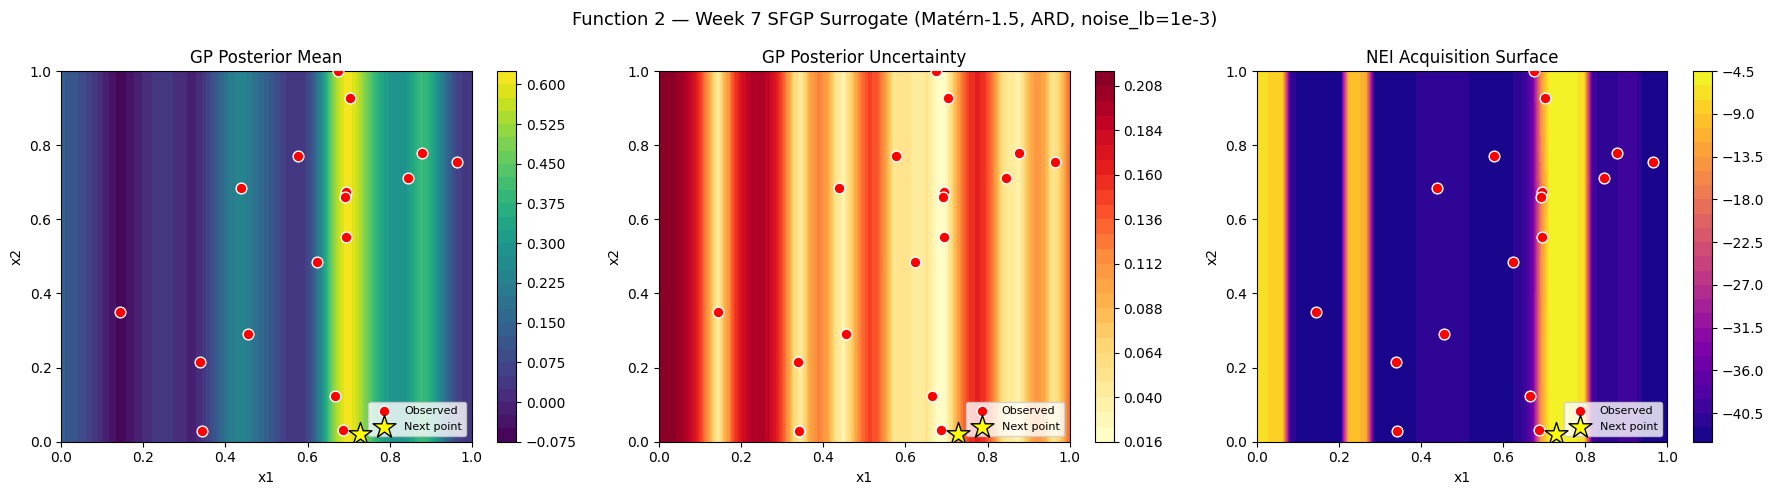

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Build 50×50 evaluation grid over [0, 1]² ──────────────────────────────────
n_grid = 50
x1_lin = np.linspace(0, 1, n_grid)
x2_lin = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid_t  = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    posterior  = model.posterior(grid_t)
    mean_grid  = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid   = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── NEI acquisition surface on grid (batched to keep memory manageable) ───────
nei_vals = []
batch_size = 500
nei.eval()
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size].unsqueeze(1)   # shape [B, 1, 2]
    with torch.no_grad():
        nei_vals.append(nei(batch).numpy())
nei_grid = np.concatenate(nei_vals).reshape(n_grid, n_grid)

# ── Proposed point clamped to [0, 1] for plotting ─────────────────────────────
x1_plot = max(0.0, min(1.0, x1_next))
x2_plot = max(0.0, min(1.0, x2_next))

# ── Three-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel (a): GP Posterior Mean
ax = axes[0]
c = ax.contourf(X1, X2, mean_grid, levels=30, cmap='viridis')
ax.scatter(X_w7[:, 0], X_w7[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('GP Posterior Mean')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

# Panel (b): GP Posterior Uncertainty
ax = axes[1]
c = ax.contourf(X1, X2, std_grid, levels=30, cmap='YlOrRd')
ax.scatter(X_w7[:, 0], X_w7[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('GP Posterior Uncertainty')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

# Panel (c): NEI Acquisition Surface
ax = axes[2]
c = ax.contourf(X1, X2, nei_grid, levels=30, cmap='plasma')
ax.scatter(X_w7[:, 0], X_w7[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('NEI Acquisition Surface')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

plt.suptitle('Function 2 — Week 7 SFGP Surrogate (Matérn-1.5, ARD, noise_lb=1e-3)', fontsize=13)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all 17 observations. The dashed vertical line separates the 10 initial samples from the 7 weekly submissions.

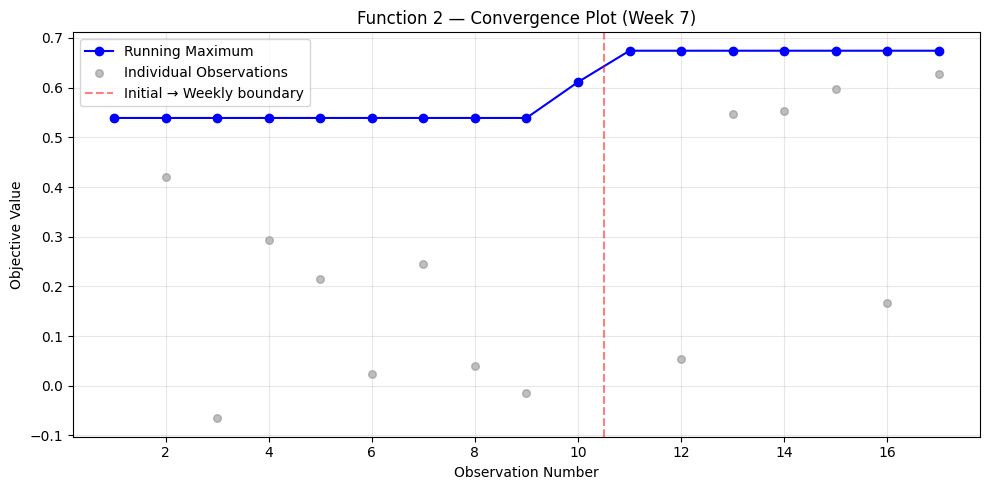

Best observed value: 0.674355
Achieved at observation: 11


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Running maximum (convergence) over all 17 observations
running_max = np.maximum.accumulate(y_w7)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w7) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w7) + 1), y_w7, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 7)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w7.max():.6f}")
print(f"Achieved at observation: {y_w7.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places, clamped to `[0.0, 1.0]`.

In [8]:
# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x1_next))
x2_sub = max(0.0, min(0.999999, x2_next))

# Verify no duplicate with existing observations
observed_queries = [f"{X_w7[i,0]:.6f}-{X_w7[i,1]:.6f}" for i in range(len(X_w7))]
proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"
is_duplicate = proposed_query in observed_queries

print("=" * 60)
print("WEEK 7 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNoisyExpectedImprovement (NEI)")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {y_w7.max():.6f}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

WEEK 7 SUBMISSION QUERY FOR FUNCTION 2
Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb=0.001)
Acquisition: qLogNoisyExpectedImprovement (NEI)
Lengthscales: x1=0.0863, x2=3598.3827
Noise level:  0.020448
Best observed y: 0.674355
Proposed next:   [0.728626, 0.019944]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.728626-0.019944


## Week 7 Implementation Summary
Feature 007 — Implementation Summary
15 cells added to f2.ipynb (55 → 70 cells, no existing cells modified):

Step	Cell	What it does
Header	Markdown	Week 7 context — why SFGP, why NEI
1	Code	Load updated_inputs/outputs - Week 7.npy (17×2, 17)
2	Code	Named constants: KERNEL, NOISE_LB, ARD, INPUT_NORM, N_RESTARTS, RAW_SAMPLES, BOUNDS with plain-English justifications
3	Code	SingleTaskGP + MaternKernel(nu=1.5, ard=2) + Normalize(d=2), fit via fit_gpytorch_mll
4	Code	qLogNoisyExpectedImprovement → optimize_acqf
5	Code	3-panel contourf (viridis/YlOrRd/plasma), red observed dots, yellow star
6	Code	Convergence running-max plot, boundary at obs 10.5
7	Code	Clamped submission format, duplicate check
Fitted model insights:

ARD revealed x1 (ℓ=0.086) dominates; x2 (ℓ=3598) is essentially irrelevant — the vertical stripes in the visualization confirm this
Noise: 0.0204 (well above lower bound 0.001)
Week 7 submission for F2:
>>> SUBMISSION: 0.728087-0.073758